# Tune Matching Tests

Validation notebook for the Dev/06 tune matching layer.

In [1]:
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

from cycle_time import RCSRamp
from machine_state_defaults import DEFAULT_QX, DEFAULT_QY
from tune_matching import (
    detect_explicit_harmonic_support,
    evaluate_di_wright_then_match,
    evaluate_di_wright_tune_programme,
    evaluate_di_wright_tune_point,
    match_tune_with_madx,
    normalise_harmonic_inputs,
)
from tune_plots import (
    calculate_harmonic_trim_quad_pattern,
    extract_programmed_trim_quad_pattern,
    plot_beta_variation,
    plot_harmonic_trim_quad_pattern,
    plot_resonance_working_points,
    plot_trim_quad_currents,
)

LATTICE_FOLDER = Path("../Lattice_Files/00_Simplified_Lattice").resolve()
OUTPUT_DIR = Path("/tmp/optics_gui_tune_matching_tests")
SEQUENCE_NAME = "synchrotron"

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

ramp = RCSRamp()
beam_state = ramp.state_at(0.0)


## Harmonic inputs and lattice support

In [2]:
harmonics = normalise_harmonic_inputs({"F8Sin": 2, "D7COS": 1.5}, d8_sin=-0.25)

assert harmonics["F8SIN"] == 2.0
assert harmonics["D7COS"] == 1.5
assert harmonics["D8SIN"] == -0.25
assert set(harmonics) == {"D7SIN", "D7COS", "D8SIN", "D8COS", "F8SIN", "F8COS", "F9SIN", "F9COS"}

support = detect_explicit_harmonic_support(LATTICE_FOLDER)
assert support["supported"], support
support


{'supported': True,
 'present': OrderedDict([('D7SIN', True),
              ('D7COS', True),
              ('D8SIN', True),
              ('D8COS', True),
              ('F8SIN', True),
              ('F8COS', True),
              ('F9SIN', True),
              ('F9COS', True)]),
 'missing': [],
 'strength_file': '/home/hr/Repositories/optics_gui/Dev/Lattice_Files/00_Simplified_Lattice/ISIS.strength'}

## MAD-X tune matching from requested Qx/Qy

In [3]:
match_result = match_tune_with_madx(
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    beam_state=beam_state,
    harmonics={"F8Sin": 0.0},
    lattice_folder=str(LATTICE_FOLDER),
    output_dir=str(OUTPUT_DIR / "match"),
    sequence_name=SEQUENCE_NAME,
    calls=50000,
)

assert abs(match_result.matched_qx - DEFAULT_QX) < 1.0e-3
assert abs(match_result.matched_qy - DEFAULT_QY) < 1.0e-3
assert np.isfinite(match_result.iqtf_A)
assert np.isfinite(match_result.iqtd_A)
assert np.isfinite(match_result.kqtf)
assert np.isfinite(match_result.kqtd)
assert {"iqtf_A", "iqtd_A", "kqtf", "kqtd"}.issubset(match_result.summary_df.columns)
match_result.summary_df


,workflow,requested_qx,requested_qy,di_wright_qx,di_wright_qy,actual_qx,actual_qy,matched_qx,matched_qy,iqtf_A,iqtd_A,kqtf,kqtd
0,match_tune_with_madx,4.331,3.731,None,None,None,None,4.331072,3.731055,-35.65516,42.936636,-0.057828,0.069638


## Di Wright settings, actual machine tune, then MAD-X match

In [4]:
di_result = evaluate_di_wright_then_match(
    di_wright_qx=DEFAULT_QX + 0.01,
    di_wright_qy=DEFAULT_QY - 0.01,
    target_qx=DEFAULT_QX,
    target_qy=DEFAULT_QY,
    beam_state=beam_state,
    harmonics={"D7SIN": 0.0, "F8Sin": 0.0},
    lattice_folder=str(LATTICE_FOLDER),
    output_dir=str(OUTPUT_DIR / "di_then_match"),
    sequence_name=SEQUENCE_NAME,
    calls=50000,
)

assert np.isfinite(di_result.actual_qx)
assert np.isfinite(di_result.actual_qy)
assert abs(di_result.matched_qx - DEFAULT_QX) < 1.0e-3
assert abs(di_result.matched_qy - DEFAULT_QY) < 1.0e-3
assert np.isfinite(di_result.trim_quad_display_dict()["iqtf_A"])
assert np.isfinite(di_result.trim_quad_display_dict()["kqtf"])
di_result.summary_df


,workflow,requested_qx,requested_qy,di_wright_qx,di_wright_qy,actual_qx,actual_qy,matched_qx,matched_qy,iqtf_A,iqtd_A,kqtf,kqtd
0,evaluate_di_wright_then_match,4.331,3.731,4.341,3.721,4.346737,3.820452,4.331072,3.731055,-35.65516,42.936636,-0.057828,0.069638


## Harmonic tune pattern from MAD-X/TWISS

In [5]:
harmonic_result = match_tune_with_madx(
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    beam_state=beam_state,
    harmonics={"F8Sin": 4.0},
    lattice_folder=str(LATTICE_FOLDER),
    output_dir=str(OUTPUT_DIR / "harmonic"),
    sequence_name=SEQUENCE_NAME,
    calls=50000,
)

expected_pattern = calculate_harmonic_trim_quad_pattern(
    harmonic_result.harmonics,
    brho_Tm=beam_state.brho_Tm,
)
programmed_pattern = extract_programmed_trim_quad_pattern(
    harmonic_result.twiss_df,
    base_kqtd=harmonic_result.kqtd,
    base_kqtf=harmonic_result.kqtf,
)

qtf_programmed = programmed_pattern[programmed_pattern["family"] == "qtf"].sort_values("superperiod")
assert len(qtf_programmed) == 10
assert np.nanmax(np.abs(qtf_programmed["delta_k"].to_numpy())) > 1.0e-3
np.testing.assert_allclose(
    qtf_programmed["delta_k"].to_numpy(),
    expected_pattern["qtf_expected_k"].to_numpy(),
    rtol=1.0e-6,
    atol=1.0e-9,
)
display(expected_pattern)
display(programmed_pattern.head())


,superperiod,qtd_expected_k,qtf_expected_k,qtd_label,qtf_label
0,0,0.0,0.000000e+00,R0_QTD,R0_QTF
1,1,0.0,-7.712478e-03,R1_QTD,R1_QTF
2,2,0.0,-4.766574e-03,R2_QTD,R2_QTF
3,3,0.0,4.766574e-03,R3_QTD,R3_QTF
4,4,0.0,7.712478e-03,R4_QTD,R4_QTF
5,5,0.0,-7.944900e-18,R5_QTD,R5_QTF
6,6,0.0,-7.712478e-03,R6_QTD,R6_QTF
7,7,0.0,-4.766574e-03,R7_QTD,R7_QTF
8,8,0.0,4.766574e-03,R8_QTD,R8_QTF
9,9,0.0,7.712478e-03,R9_QTD,R9_QTF


,superperiod,family,name,l,k1l,k1,delta_k
0,0,qtd,sp0_qtd:1,0.307,0.021366,0.069596,0.0
1,1,qtd,sp1_qtd:1,0.307,0.021366,0.069596,0.0
2,2,qtd,sp2_qtd:1,0.307,0.021366,0.069596,0.0
3,3,qtd,sp3_qtd:1,0.307,0.021366,0.069596,0.0
4,4,qtd,sp4_qtd:1,0.307,0.021366,0.069596,0.0


## Full-cycle zero-harmonic tune programme

This uses the set tune programme from `isis_2024/Methods/Match_Tune/Full_Cycle_Machine_Tunes.ipynb` and evaluates the actual MAD-X tunes from Di Wright machine states with all harmonic tune settings at zero.

In [6]:
full_cycle_time_ms = np.array([-0.1, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0, 9.0, 10.0])
full_cycle_set_qx = np.array([4.315, 4.270, 4.270, 4.250, 4.235, 4.205, 4.170, 4.190, 4.18, 4.18, 4.18, 4.17, 4.165, 4.165, 4.165, 4.18, 4.18, 4.175])
full_cycle_set_qy = np.array([3.82, 3.82, 3.81, 3.805, 3.800, 3.825, 3.680, 3.680, 3.69, 3.7, 3.7, 3.695, 3.695, 3.695, 3.692, 3.69, 3.685, 3.665])

assert len(full_cycle_time_ms) == len(full_cycle_set_qx) == len(full_cycle_set_qy) == 18


In [7]:
full_cycle_df = evaluate_di_wright_tune_programme(
    cycle_times_ms=full_cycle_time_ms,
    qx_values=full_cycle_set_qx,
    qy_values=full_cycle_set_qy,
    harmonics={},
    lattice_folder=str(LATTICE_FOLDER),
    output_dir=str(OUTPUT_DIR / "full_cycle_zero_harmonics"),
    sequence_name=SEQUENCE_NAME,
)

required_columns = {
    "cycle_time_ms",
    "set_qx",
    "set_qy",
    "actual_qx",
    "actual_qy",
    "iqtf_A",
    "iqtd_A",
    "kqtf",
    "kqtd",
    "brho_Tm",
    "normalised_momentum",
}
assert required_columns.issubset(full_cycle_df.columns)
assert len(full_cycle_df) == 18
assert np.isfinite(full_cycle_df["actual_qx"]).all()
assert np.isfinite(full_cycle_df["actual_qy"]).all()
assert np.isfinite(full_cycle_df["iqtf_A"]).all()
assert np.isfinite(full_cycle_df["iqtd_A"]).all()
assert np.isfinite(full_cycle_df["kqtf"]).all()
assert np.isfinite(full_cycle_df["kqtd"]).all()

full_cycle_df


,index,cycle_time_ms,set_qx,set_qy,actual_qx,actual_qy,actual_dqx,actual_dqy,iqtf_A,iqtd_A,kqtf,kqtd,brho_Tm,normalised_momentum,twiss_rows,output_dir,warnings
0,0,-0.1,4.315,3.820,4.321492,3.925210,-13.350612,-14.243066,22.855556,-32.326592,0.037069,-0.052430,1.231290,1.000000,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
1,1,0.0,4.270,3.820,4.274168,3.922285,-12.512860,-14.048933,9.770314,-25.269383,0.015846,-0.040984,1.231290,1.000000,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
2,2,0.5,4.270,3.810,4.274902,3.909680,-12.319134,-13.719832,6.801398,-21.744912,0.010639,-0.034015,1.253757,1.018247,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
3,3,1.0,4.250,3.805,4.259237,3.899583,-11.530938,-12.984345,-0.730981,-17.441228,-0.001031,-0.024591,1.320606,1.072538,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
4,4,1.5,4.235,3.800,4.252273,3.889060,-10.677497,-12.041175,-7.653006,-13.882885,-0.009200,-0.016689,1.430189,1.161537,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
5,5,2.0,4.205,3.825,4.237434,3.903237,-9.668652,-11.161587,-9.732197,-21.853846,-0.009588,-0.021531,1.579809,1.283052,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
6,6,2.5,4.170,3.680,4.229582,3.795588,-8.696976,-9.573312,-89.744195,64.837013,-0.070773,0.051131,1.765782,1.434091,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
7,7,3.0,4.190,3.680,4.251313,3.798816,-8.220175,-8.859041,-91.442285,67.779589,-0.057149,0.042360,1.983529,1.610935,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
8,8,3.5,4.180,3.690,4.254364,3.807188,-7.624471,-8.223632,-102.367144,71.878551,-0.050721,0.035615,2.227687,1.809229,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]
9,9,4.0,4.180,3.700,4.262101,3.814129,-7.175560,-7.702015,-108.268107,72.492202,-0.042861,0.028698,2.492244,2.024092,586,/tmp/optics_gui_tune_matching_tests/full_cycle...,[]


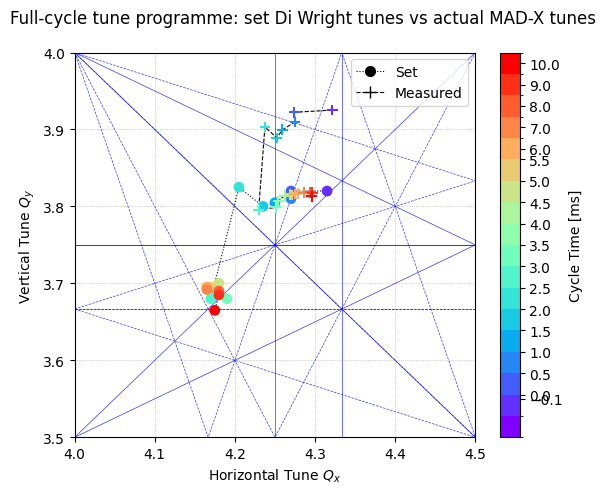

In [8]:
fig_cycle, ax_cycle = plot_resonance_working_points(
    requested_qx=full_cycle_df["set_qx"],
    requested_qy=full_cycle_df["set_qy"],
    actual_qx=full_cycle_df["actual_qx"],
    actual_qy=full_cycle_df["actual_qy"],
    cycle_times=full_cycle_df["cycle_time_ms"],
    xlims=(4.0, 4.5),
    ylims=(3.5, 4.0),
)
fig_cycle.suptitle("Full-cycle tune programme: set Di Wright tunes vs actual MAD-X tunes")
display(fig_cycle)

assert fig_cycle is ax_cycle.figure
plt.close(fig_cycle)


## Plot helper smoke tests

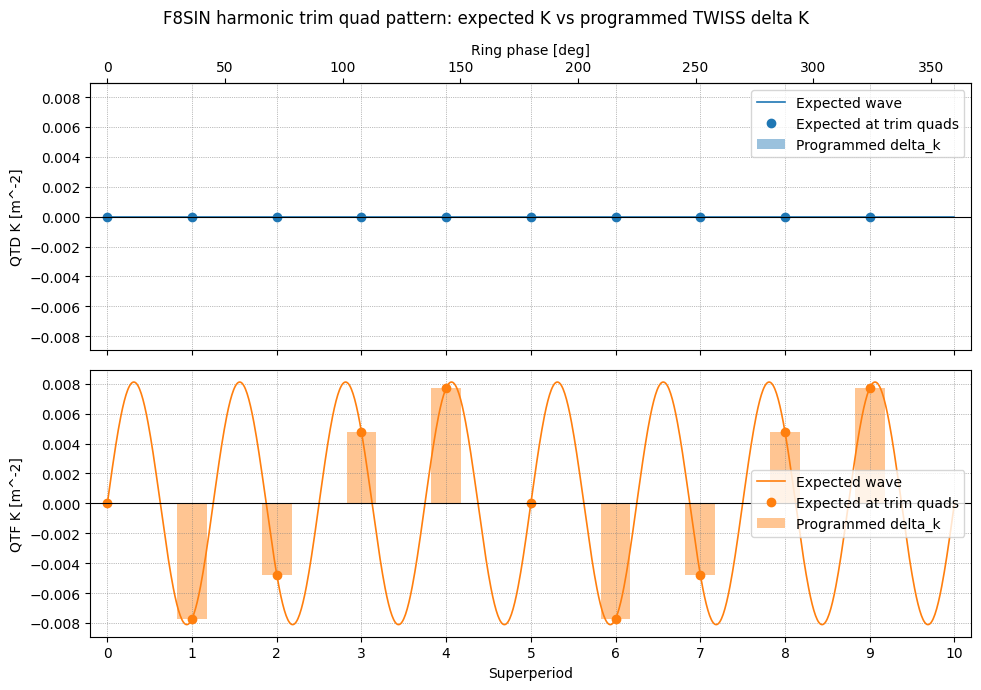

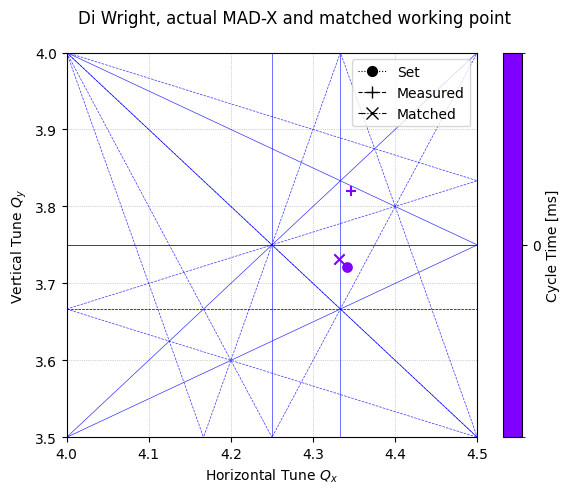

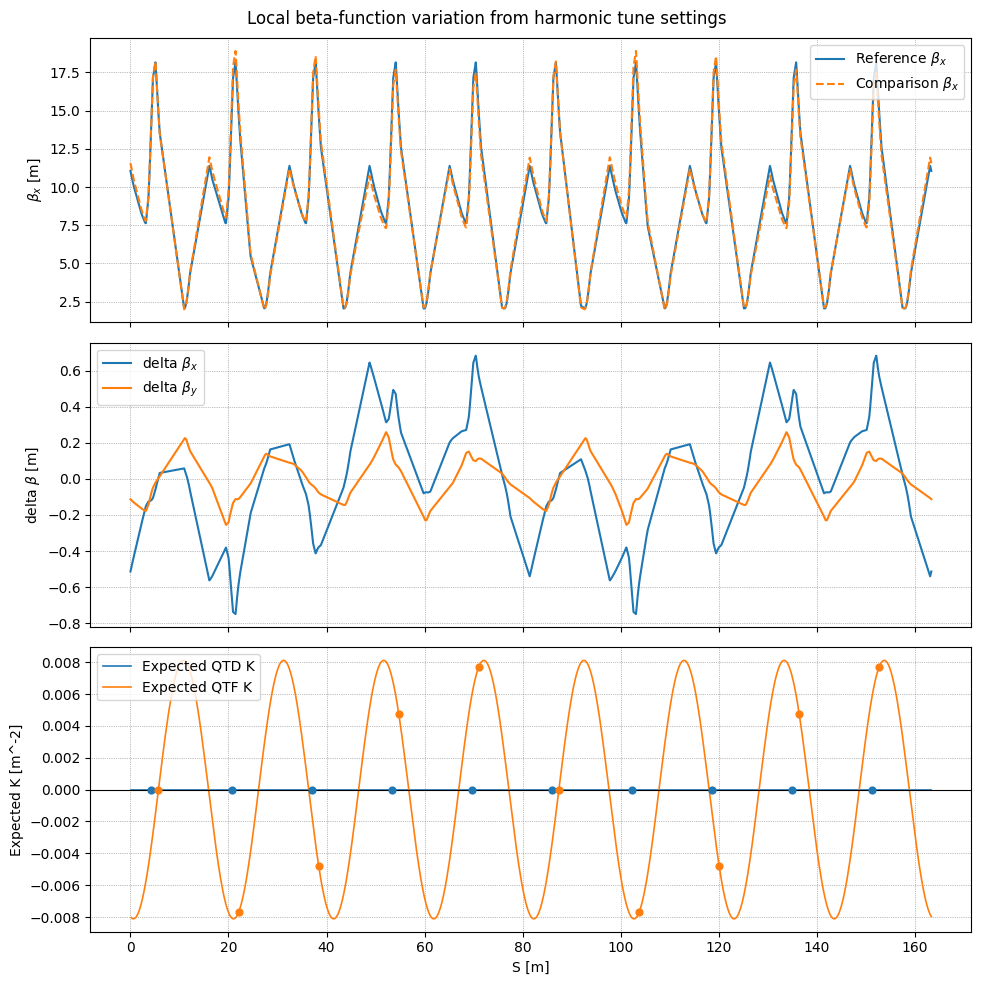

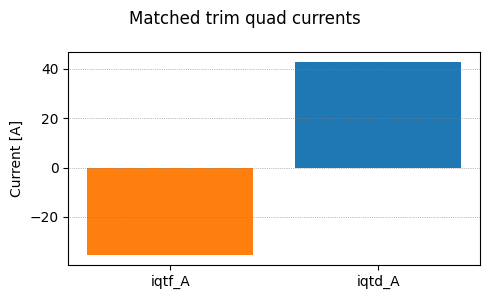

In [9]:
fig_harm, ax_harm = plot_harmonic_trim_quad_pattern(
    expected_pattern,
    programmed_pattern,
    harmonics=harmonic_result.harmonics,
    brho_Tm=beam_state.brho_Tm,
)
fig_harm.suptitle("F8SIN harmonic trim quad pattern: expected K vs programmed TWISS delta K")
display(fig_harm)

fig_res, ax_res = plot_resonance_working_points(
    requested_qx=[di_result.di_wright_qx],
    requested_qy=[di_result.di_wright_qy],
    actual_qx=[di_result.actual_qx],
    actual_qy=[di_result.actual_qy],
    matched_qx=[di_result.matched_qx],
    matched_qy=[di_result.matched_qy],
    cycle_times=[beam_state.cycle_time_ms],
)
fig_res.suptitle("Di Wright, actual MAD-X and matched working point")
display(fig_res)

fig_beta, ax_beta = plot_beta_variation(
    match_result.twiss_df,
    harmonic_result.twiss_df,
    harmonics=harmonic_result.harmonics,
    brho_Tm=beam_state.brho_Tm,
)
fig_beta.suptitle("Local beta-function variation from harmonic tune settings")
display(fig_beta)

fig_curr, ax_curr = plot_trim_quad_currents(harmonic_result)
fig_curr.suptitle("Matched trim quad currents")
display(fig_curr)

assert fig_res is ax_res.figure
assert fig_harm is ax_harm[0].figure
assert fig_curr is ax_curr.figure
assert fig_beta is ax_beta[0].figure

plt.close("all")


## Full-cycle harmonic spot checks

Use selected points from the full-cycle zero-harmonic dataframe, add harmonic settings, and compare expected harmonic trim-quad patterns against programmed TWISS values. These cases cover three single harmonics plus sine/cosine, multiple-cosine and multiple-sine combinations.

In [10]:
harmonic_spot_cases = [
    {
        "label": "single_D7SIN",
        "full_cycle_index": 1,
        "harmonics": {"D7SIN": 4.0},
    },
    {
        "label": "single_F8SIN",
        "full_cycle_index": 6,
        "harmonics": {"F8Sin": 4.0},
    },
    {
        "label": "single_F9COS",
        "full_cycle_index": 12,
        "harmonics": {"F9COS": 3.0},
    },
    {
        "label": "one_sine_one_cosine",
        "full_cycle_index": 3,
        "harmonics": {"D7SIN": 3.0, "F8COS": -2.0},
    },
    {
        "label": "multiple_cosine",
        "full_cycle_index": 9,
        "harmonics": {"D7COS": 2.5, "D8COS": -1.5, "F9COS": 2.0},
    },
    {
        "label": "multiple_sine",
        "full_cycle_index": 15,
        "harmonics": {"D8SIN": -2.0, "F8SIN": 3.0, "F9SIN": 1.5},
    },
]

assert len(harmonic_spot_cases) == 6


In [11]:
harmonic_spot_results = []

for case in harmonic_spot_cases:
    row = full_cycle_df.iloc[case["full_cycle_index"]]
    zero_result = evaluate_di_wright_tune_point(
        cycle_time_ms=row["cycle_time_ms"],
        qx=row["set_qx"],
        qy=row["set_qy"],
        harmonics={},
        lattice_folder=str(LATTICE_FOLDER),
        output_dir=str(OUTPUT_DIR / "harmonic_spot_checks" / case["label"] / "zero"),
        sequence_name=SEQUENCE_NAME,
    )
    harmonic_point_result = evaluate_di_wright_tune_point(
        cycle_time_ms=row["cycle_time_ms"],
        qx=row["set_qx"],
        qy=row["set_qy"],
        harmonics=case["harmonics"],
        lattice_folder=str(LATTICE_FOLDER),
        output_dir=str(OUTPUT_DIR / "harmonic_spot_checks" / case["label"] / "harmonic"),
        sequence_name=SEQUENCE_NAME,
    )

    expected_df = calculate_harmonic_trim_quad_pattern(
        harmonic_point_result.harmonics,
        brho_Tm=zero_result.machine_state.beam_state.brho_Tm,
    )
    programmed_df = extract_programmed_trim_quad_pattern(
        harmonic_point_result.twiss_df,
        base_kqtd=harmonic_point_result.kqtd,
        base_kqtf=harmonic_point_result.kqtf,
    )

    qtd_programmed = programmed_df[programmed_df["family"] == "qtd"].sort_values("superperiod")
    qtf_programmed = programmed_df[programmed_df["family"] == "qtf"].sort_values("superperiod")
    np.testing.assert_allclose(
        qtd_programmed["delta_k"].to_numpy(),
        expected_df["qtd_expected_k"].to_numpy(),
        rtol=1.0e-6,
        atol=1.0e-9,
    )
    np.testing.assert_allclose(
        qtf_programmed["delta_k"].to_numpy(),
        expected_df["qtf_expected_k"].to_numpy(),
        rtol=1.0e-6,
        atol=1.0e-9,
    )

    harmonic_spot_results.append(
        {
            "case": case,
            "row": row,
            "zero_result": zero_result,
            "harmonic_result": harmonic_point_result,
            "expected_df": expected_df,
            "programmed_df": programmed_df,
        }
    )

summary_rows = []
for item in harmonic_spot_results:
    result = item["harmonic_result"]
    row = item["row"]
    summary_rows.append(
        {
            "label": item["case"]["label"],
            "cycle_time_ms": row["cycle_time_ms"],
            "set_qx": row["set_qx"],
            "set_qy": row["set_qy"],
            "actual_qx": result.actual_qx,
            "actual_qy": result.actual_qy,
            "iqtf_A": result.iqtf_A,
            "iqtd_A": result.iqtd_A,
            "kqtf": result.kqtf,
            "kqtd": result.kqtd,
            "harmonics": dict(result.harmonics),
        }
    )

harmonic_spot_summary_df = __import__("pandas").DataFrame(summary_rows)
harmonic_spot_summary_df


,label,cycle_time_ms,set_qx,set_qy,actual_qx,actual_qy,iqtf_A,iqtd_A,kqtf,kqtd,harmonics
0,single_D7SIN,0.0,4.270,3.820,4.274095,3.922122,9.770314,-25.269383,0.015846,-0.040984,"{'D7SIN': 4.0, 'D7COS': 0.0, 'D8SIN': 0.0, 'D8..."
1,single_F8SIN,2.5,4.170,3.680,4.229399,3.795628,-89.744195,64.837013,-0.070773,0.051131,"{'D7SIN': 0.0, 'D7COS': 0.0, 'D8SIN': 0.0, 'D8..."
2,single_F9COS,5.5,4.165,3.695,4.274719,3.816138,-161.198812,108.894056,-0.035496,0.023979,"{'D7SIN': 0.0, 'D7COS': 0.0, 'D8SIN': 0.0, 'D8..."
3,one_sine_one_cosine,1.0,4.250,3.805,4.259120,3.899540,-0.730981,-17.441228,-0.001031,-0.024591,"{'D7SIN': 3.0, 'D7COS': 0.0, 'D8SIN': 0.0, 'D8..."
4,multiple_cosine,4.0,4.180,3.700,4.262116,3.814124,-108.268107,72.492202,-0.042861,0.028698,"{'D7SIN': 0.0, 'D7COS': 2.5, 'D8SIN': 0.0, 'D8..."
5,multiple_sine,8.0,4.180,3.690,4.294141,3.818372,-208.278944,146.246033,-0.024929,0.017504,"{'D7SIN': 0.0, 'D7COS': 0.0, 'D8SIN': -2.0, 'D..."


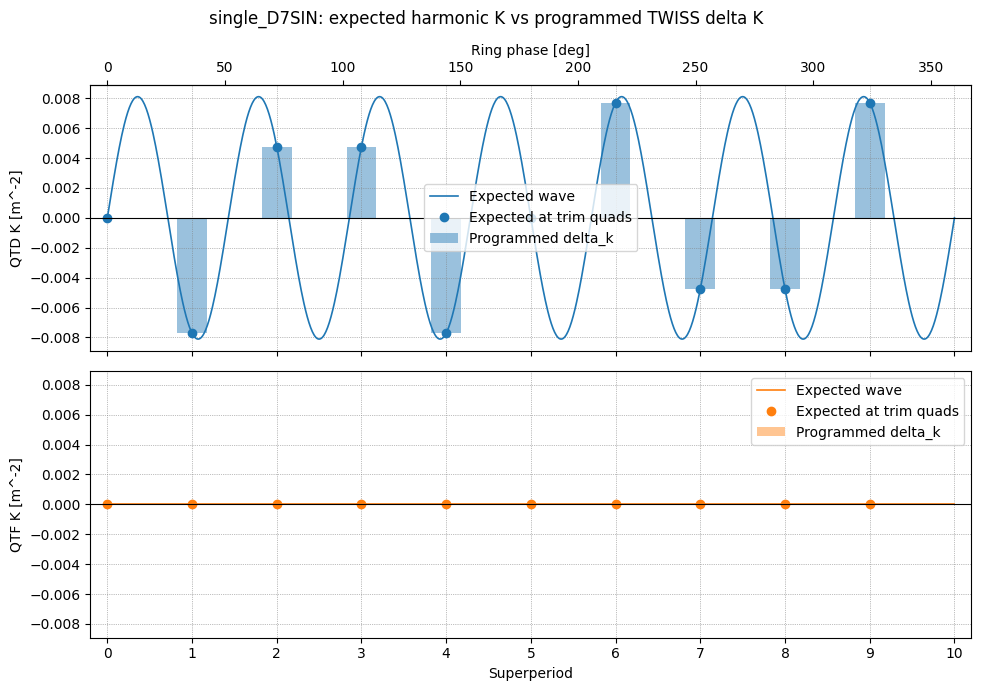

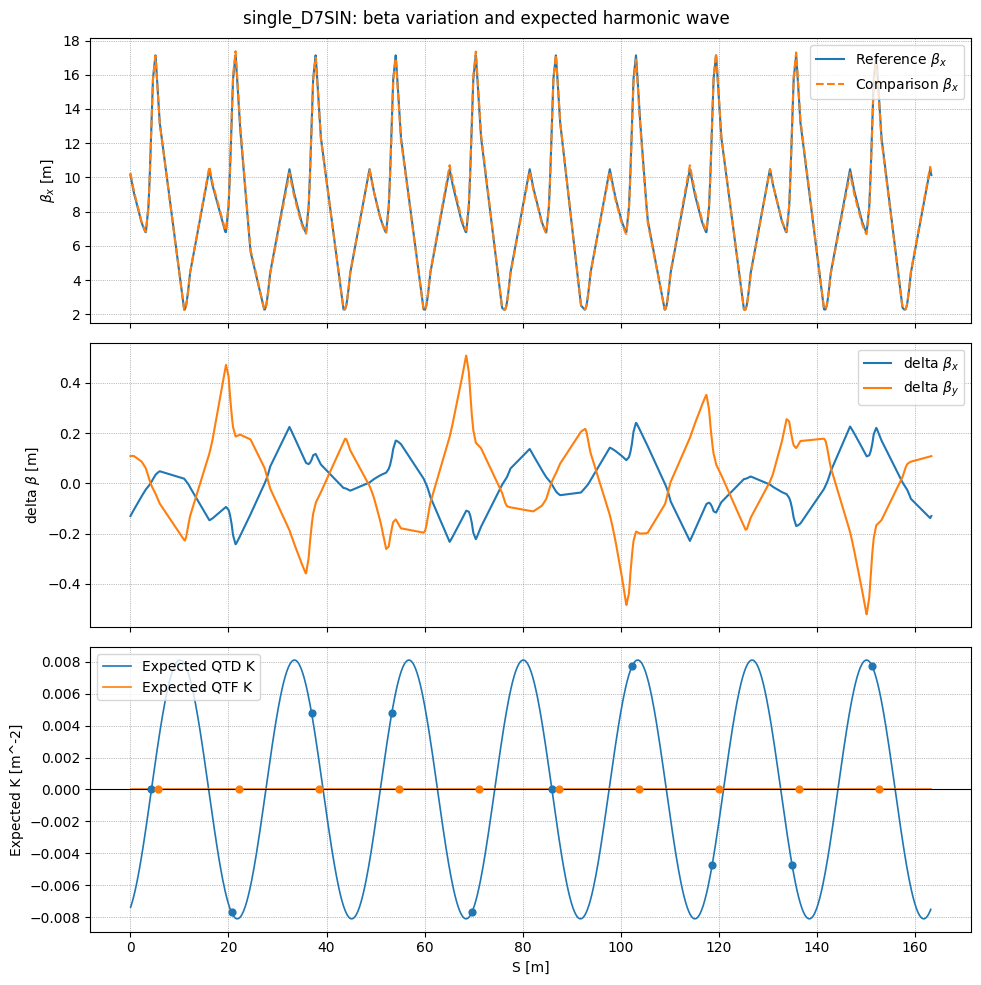

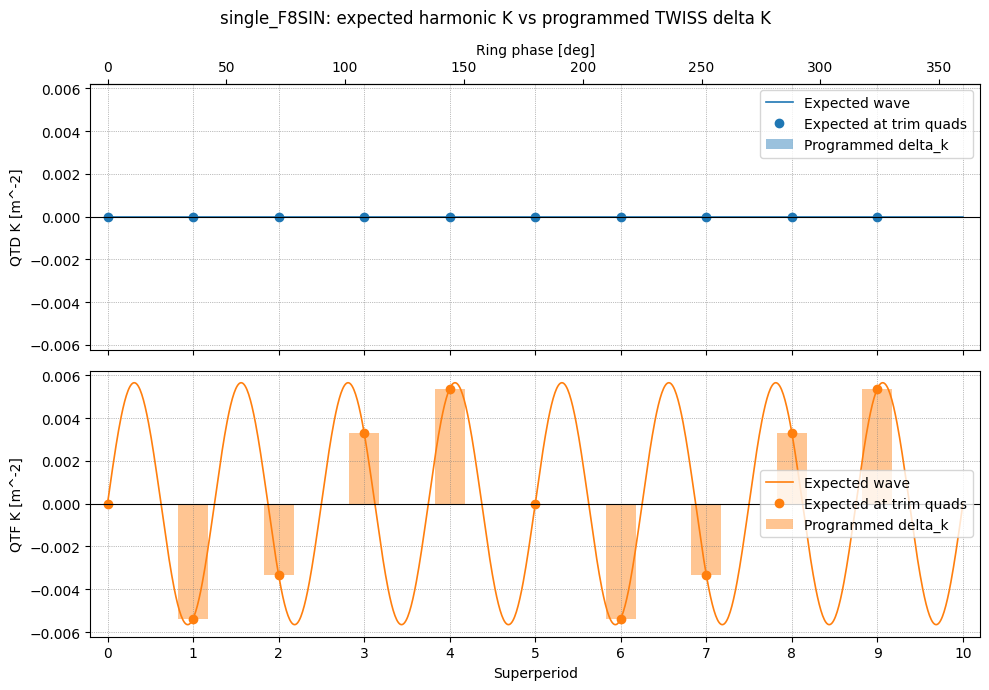

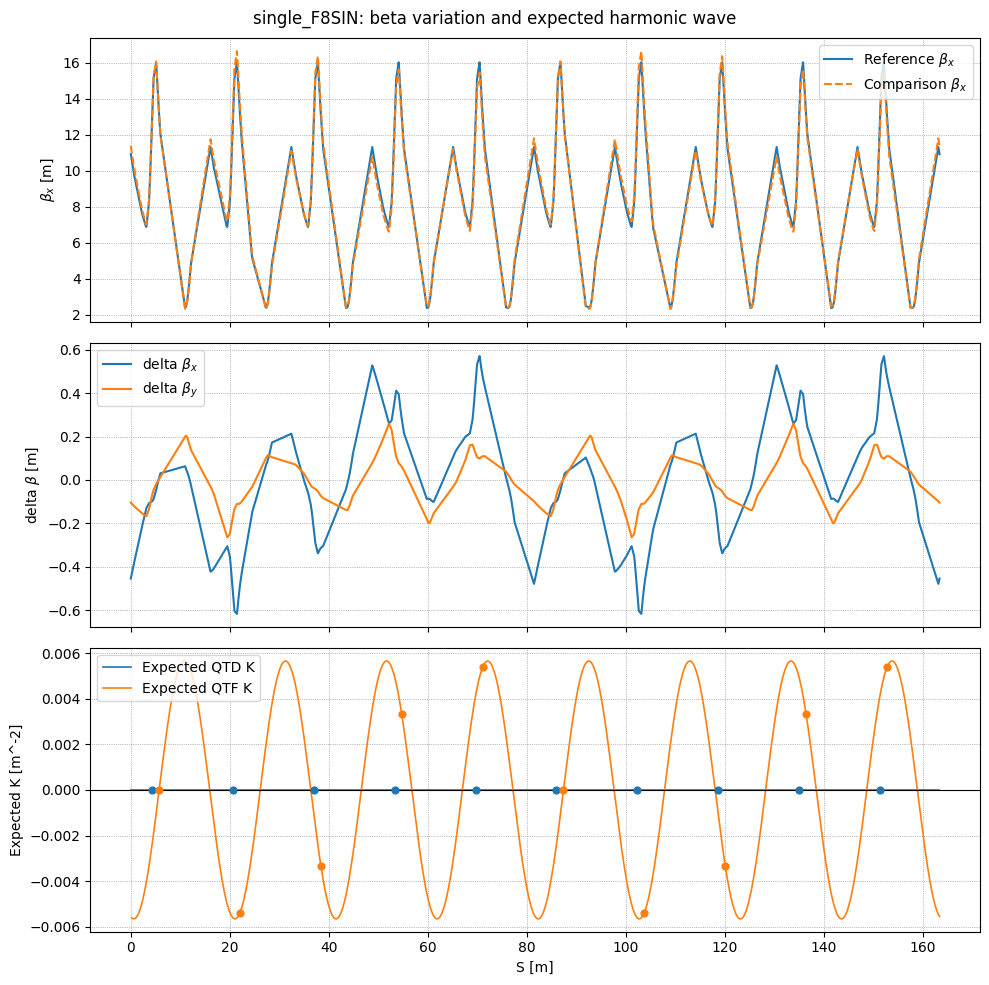

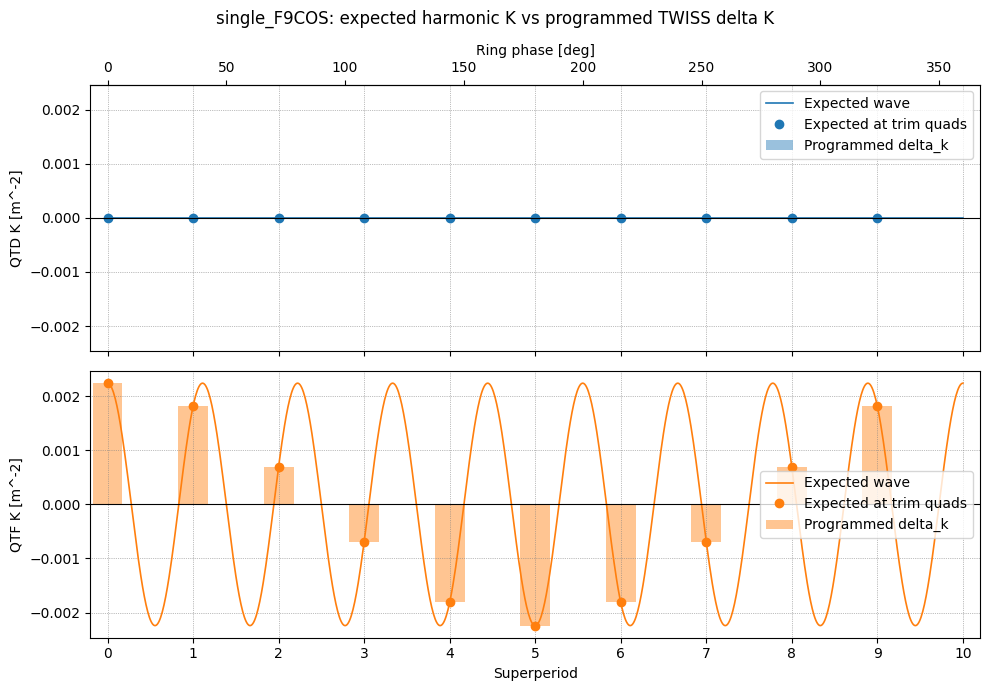

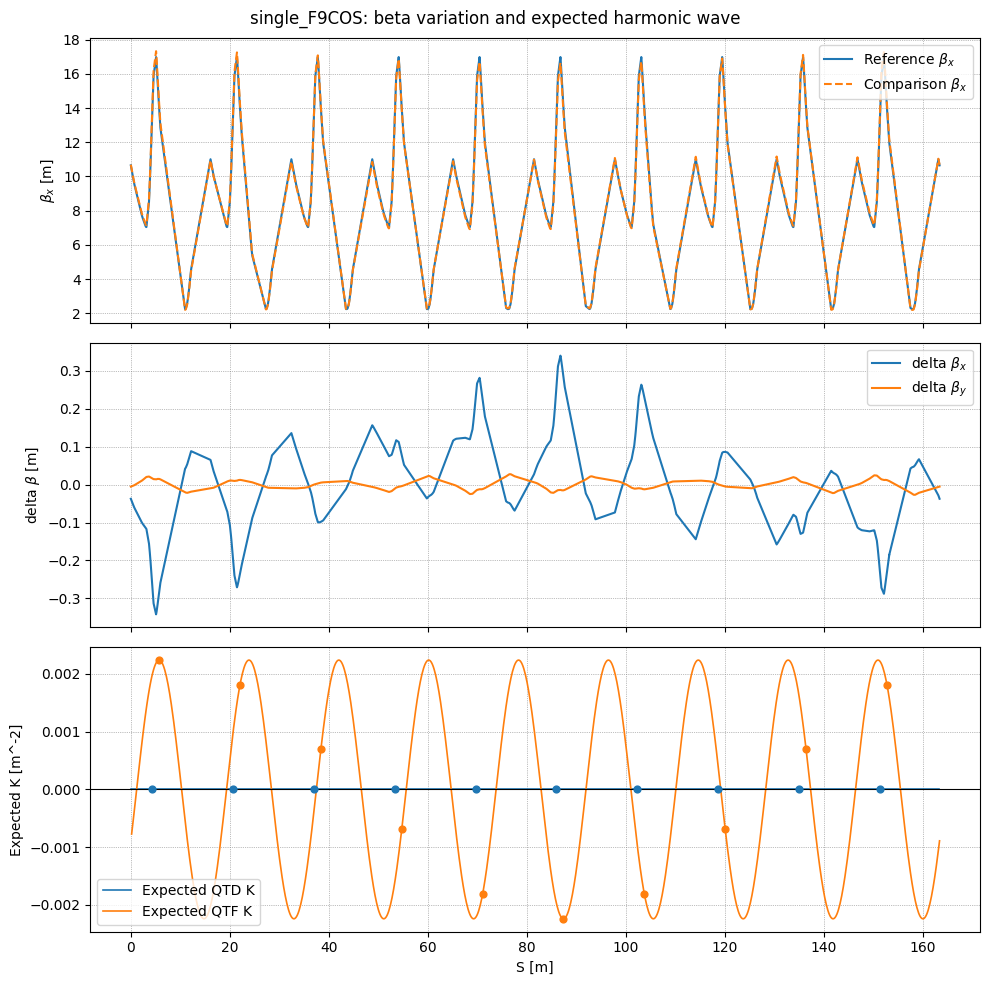

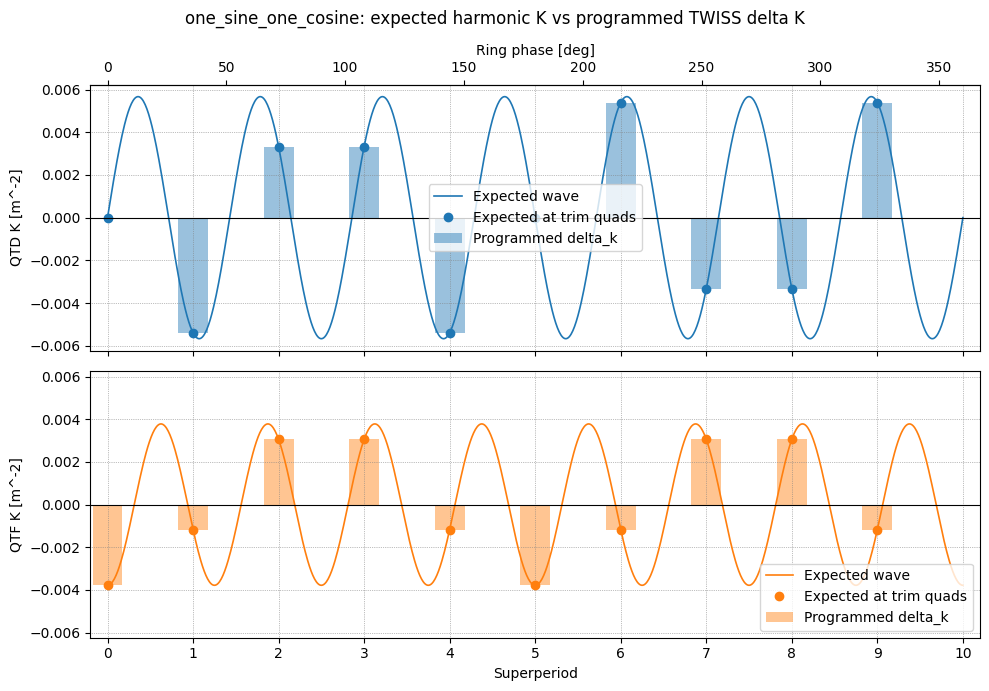

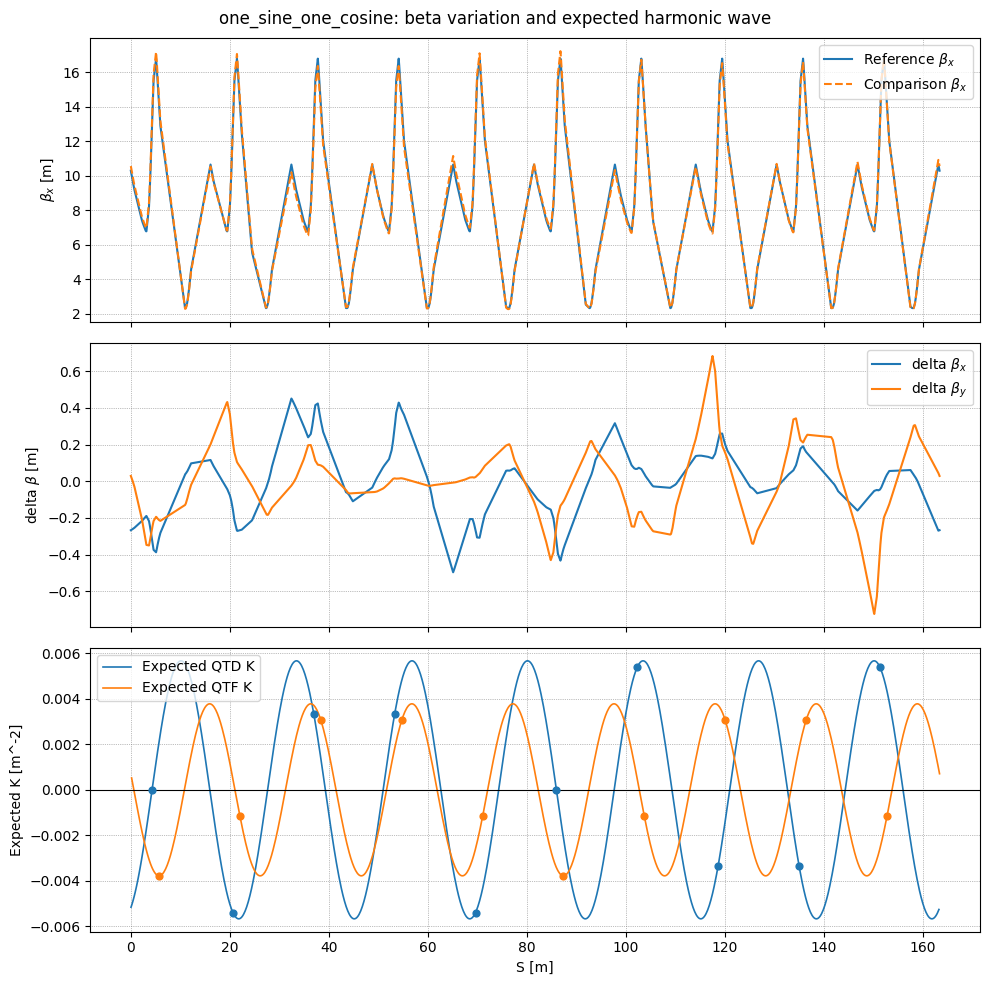

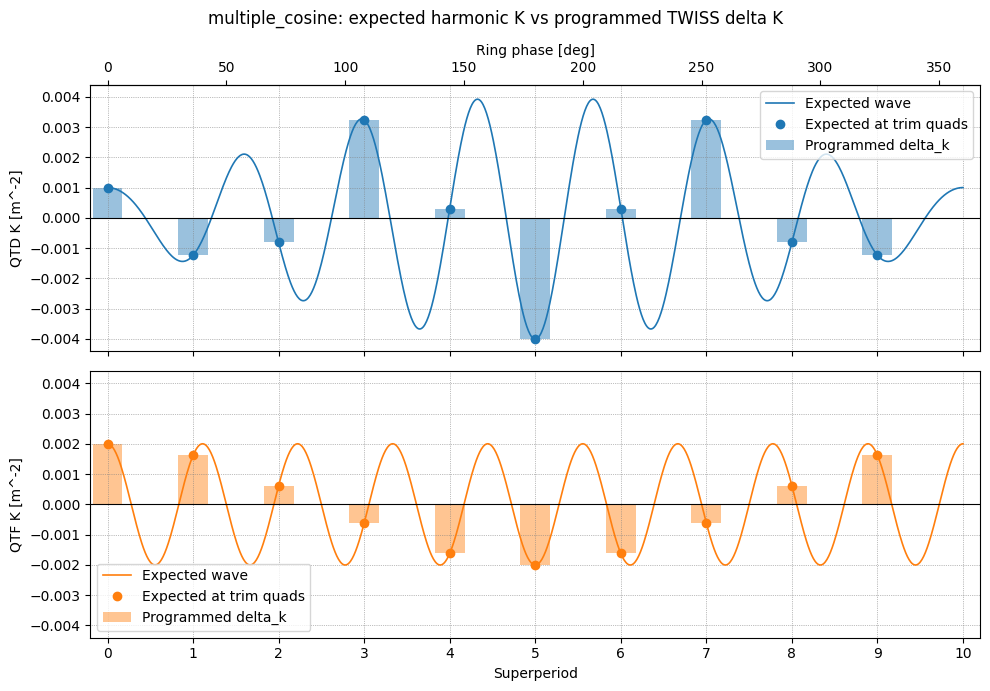

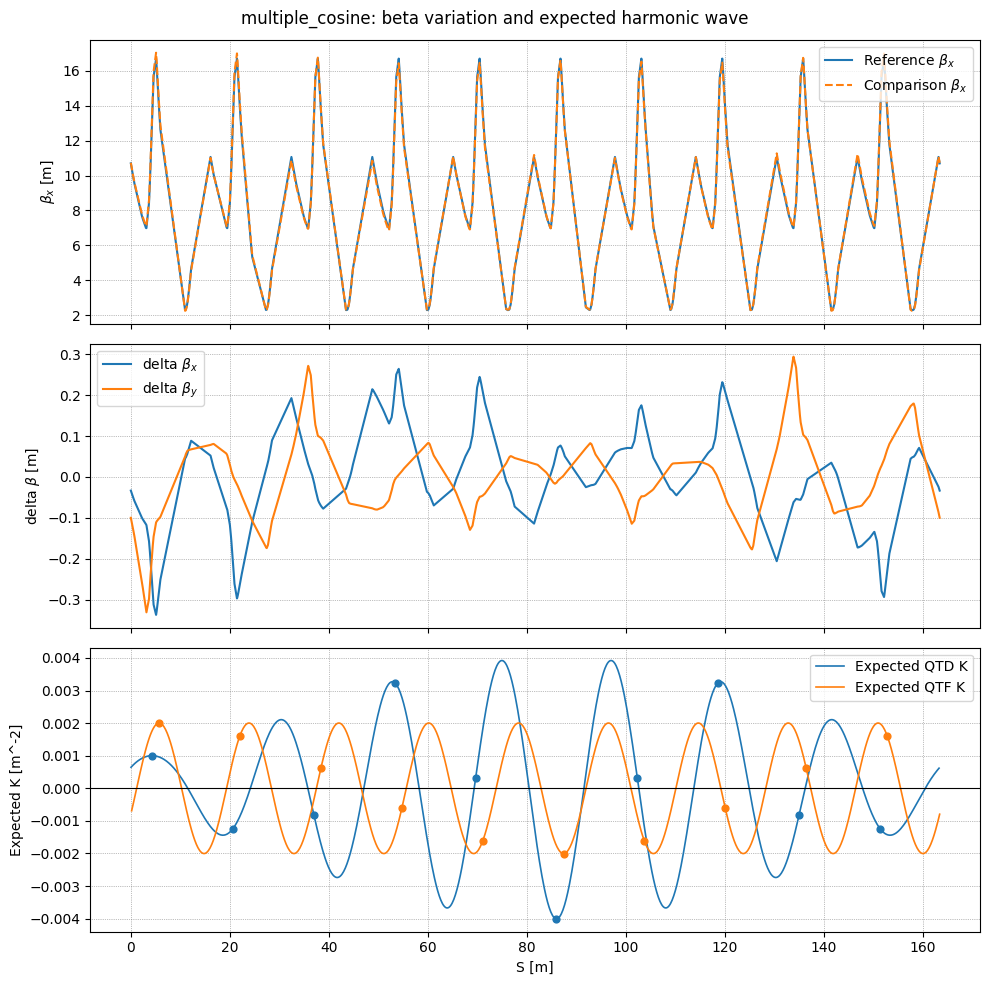

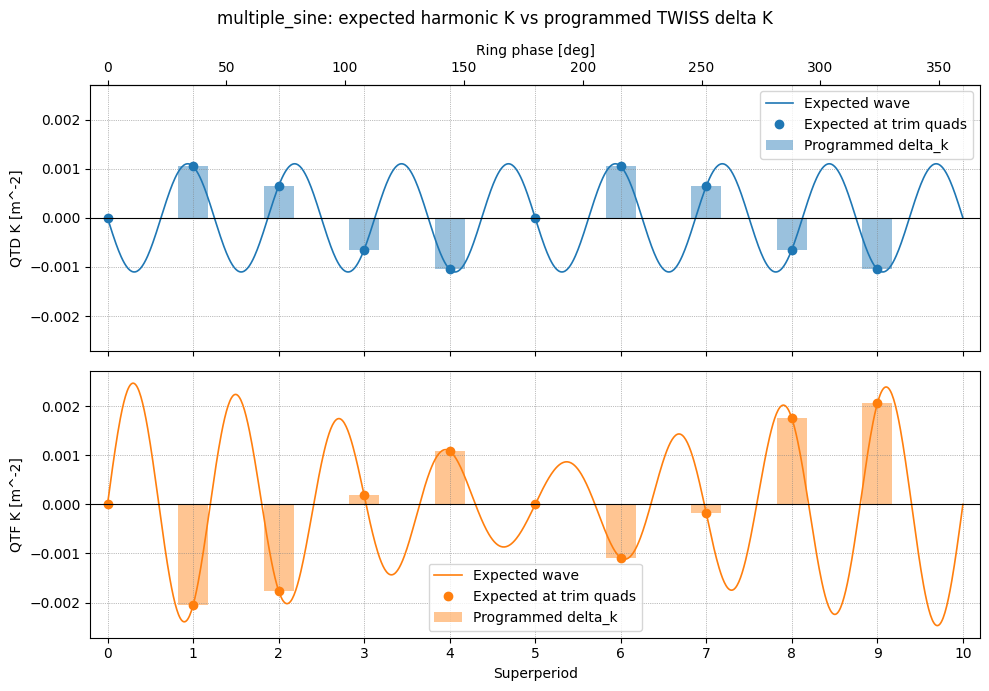

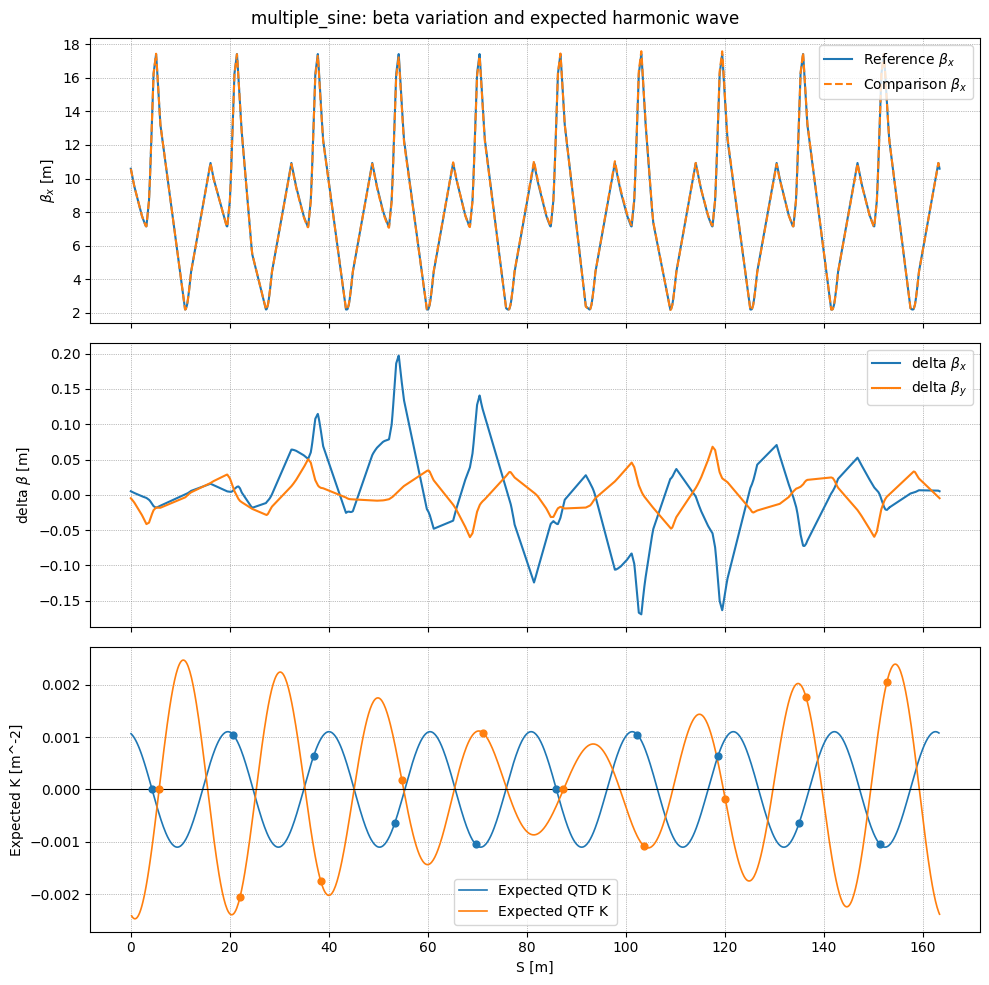

In [12]:
for item in harmonic_spot_results:
    case = item["case"]
    zero_result = item["zero_result"]
    harmonic_point_result = item["harmonic_result"]

    fig_harmonic_case, ax_harmonic_case = plot_harmonic_trim_quad_pattern(
        item["expected_df"],
        item["programmed_df"],
        harmonics=harmonic_point_result.harmonics,
        brho_Tm=zero_result.machine_state.beam_state.brho_Tm,
    )
    fig_harmonic_case.suptitle(f"{case['label']}: expected harmonic K vs programmed TWISS delta K")
    display(fig_harmonic_case)

    fig_beta_case, ax_beta_case = plot_beta_variation(
        zero_result.twiss_df,
        harmonic_point_result.twiss_df,
        harmonics=harmonic_point_result.harmonics,
        brho_Tm=zero_result.machine_state.beam_state.brho_Tm,
    )
    fig_beta_case.suptitle(f"{case['label']}: beta variation and expected harmonic wave")
    display(fig_beta_case)

    assert fig_harmonic_case is ax_harmonic_case[0].figure
    assert fig_beta_case is ax_beta_case[0].figure

plt.close("all")
